# 📉 Phase 5: Autonomous Markdown & Yield Optimization

**Project Rationale:**
Traditional static discounting (e.g., a flat 10% off at the end of the week) leaves gross margin on the table and often fails to clear inventory before spoilage. To optimize yield and minimize waste—especially for highly perishable SKU categories—we are transitioning from reactive, rule-based pricing to proactive, condition-based optimization.

**What We Are Trying to Achieve:**
* **Time-Series Forecasting:** Predict daily demand fluctuations based on historical sales velocity, current inventory positions, and product aging.
* **Dynamic Price Elasticity:** Calculate the exact, optimal markdown threshold that balances maximum margin recovery with guaranteed inventory clearance before the sell-by date.
* **Prescriptive Execution:** Generate structured, autonomous markdown recommendations that the data analytics team can instantly validate and push to category leads for immediate operational execution.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set random seed for reproducible testing
np.random.seed(42)

# 1. Generate 30 days of historical data for highly perishable items
dates = [datetime(2026, 8, 1) + timedelta(days=i) for i in range(30)]
data = []
skus = ["Premium Spinach 250g", "Farm Fresh Tomatoes 1kg", "Robusta Bananas 500g"]

for date in dates:
    for sku in skus:
        # Define base constraints for each SKU
        shelf_life = 4 if "Spinach" in sku else (7 if "Tomatoes" in sku else 5)
        base_price = 45.0 if "Spinach" in sku else (60.0 if "Tomatoes" in sku else 55.0)

        # Simulate inventory aging (1 to 5 days on the shelf)
        days_on_shelf = np.random.randint(1, 6)

        # Simulate historical manual discounting: items close to expiry sometimes got a 10-20% cut
        historical_discount = np.random.choice([0.0, 0.1, 0.2]) if days_on_shelf >= shelf_life - 2 else 0.0

        # Simulate sales velocity (price elasticity: higher discount = slight bump in units sold)
        base_demand = np.random.normal(50, 15)
        units_sold = int(base_demand * (1 + (historical_discount * 2.5)))

        # Calculate remaining inventory for the day
        current_inventory = max(0, 300 - units_sold - (days_on_shelf * 15))

        data.append({
            "date": date,
            "sku_name": sku,
            "shelf_life_days": shelf_life,
            "days_on_shelf": days_on_shelf,
            "current_inventory": current_inventory,
            "base_price": base_price,
            "historical_discount": historical_discount,
            "units_sold": max(0, units_sold)
        })

# 2. Load into a DataFrame and review the first 10 rows
df = pd.DataFrame(data)
display(df.head(10))

,date,sku_name,shelf_life_days,days_on_shelf,current_inventory,base_price,historical_discount,units_sold
0,2026-08-01,Premium Spinach 250g,4,4,182,45.0,0.0,58
1,2026-08-01,Farm Fresh Tomatoes 1kg,7,5,164,60.0,0.2,61
2,2026-08-01,Robusta Bananas 500g,5,2,216,55.0,0.0,54
3,2026-08-02,Premium Spinach 250g,4,3,174,45.0,0.1,81
4,2026-08-02,Farm Fresh Tomatoes 1kg,7,5,159,60.0,0.1,66
5,2026-08-02,Robusta Bananas 500g,5,2,219,55.0,0.0,51
6,2026-08-03,Premium Spinach 250g,4,4,169,45.0,0.0,71
7,2026-08-03,Farm Fresh Tomatoes 1kg,7,5,152,60.0,0.0,73
8,2026-08-03,Robusta Bananas 500g,5,1,272,55.0,0.0,13
9,2026-08-04,Premium Spinach 250g,4,4,152,45.0,0.2,88


## Step 2: Spoilage Risk Calculation
To prevent write-offs, the system calculates the remaining days_to_expiry and compares it against the current days_of_supply (how long the inventory will last at its current sales velocity). If the days of supply exceed the days to expiry, the system automatically flags the item as high risk, indicating a markdown is mathematically required to clear the stock.

In [2]:
# 1. Calculate remaining shelf life
df['days_to_expiry'] = df['shelf_life_days'] - df['days_on_shelf']

# 2. Calculate current Days of Supply (DOS) based on today's sales velocity
# We add a small epsilon (0.1) to prevent division by zero errors if units_sold is 0
df['days_of_supply'] = round(df['current_inventory'] / (df['units_sold'] + 0.1), 1)

# 3. Define the operational risk logic
def flag_spoilage_risk(row):
    if row['days_to_expiry'] <= 0:
        return "🚨 Expired / Write-off"
    elif row['days_of_supply'] > row['days_to_expiry']:
        return "⚠️ High Risk (Markdown Required)"
    elif row['days_to_expiry'] <= 2:
        return "🟡 Watchlist"
    else:
        return "✅ Safe"

# 4. Apply the operational flags
df['spoilage_risk'] = df.apply(flag_spoilage_risk, axis=1)

# 5. Display the risk dashboard
display(df[['date', 'sku_name', 'current_inventory', 'days_to_expiry', 'days_of_supply', 'spoilage_risk']].head(10))

,date,sku_name,current_inventory,days_to_expiry,days_of_supply,spoilage_risk
0,2026-08-01,Premium Spinach 250g,182,0,3.1,🚨 Expired / Write-off
1,2026-08-01,Farm Fresh Tomatoes 1kg,164,2,2.7,⚠️ High Risk (Markdown Required)
2,2026-08-01,Robusta Bananas 500g,216,3,4.0,⚠️ High Risk (Markdown Required)
3,2026-08-02,Premium Spinach 250g,174,1,2.1,⚠️ High Risk (Markdown Required)
4,2026-08-02,Farm Fresh Tomatoes 1kg,159,2,2.4,⚠️ High Risk (Markdown Required)
5,2026-08-02,Robusta Bananas 500g,219,3,4.3,⚠️ High Risk (Markdown Required)
6,2026-08-03,Premium Spinach 250g,169,0,2.4,🚨 Expired / Write-off
7,2026-08-03,Farm Fresh Tomatoes 1kg,152,2,2.1,⚠️ High Risk (Markdown Required)
8,2026-08-03,Robusta Bananas 500g,272,4,20.8,⚠️ High Risk (Markdown Required)
9,2026-08-04,Premium Spinach 250g,152,0,1.7,🚨 Expired / Write-off


## Step 3: Dynamic Price Elasticity & Markdown Prescription
Knowing an item will spoil is only half the battle. This engine calculates the exact target sales velocity required to clear the remaining inventory before the expiry date. By applying a baseline price elasticity model (assuming a 10% discount drives a 25% increase in volume), the system automatically prescribes the minimum markdown needed to bridge the gap between current sales pace and the required clearance pace, capping maximum discounts at 50% to protect gross margins.

In [3]:
# 1. Filter out already expired stock (write-offs cannot be sold)
active_df = df[df['days_to_expiry'] > 0].copy()

# 2. Define the markdown optimization engine
def calculate_optimal_markdown(row):
    # No markdown needed for healthy stock
    if row['spoilage_risk'] in ["✅ Safe", "🟡 Watchlist"]:
        return 0.0

    # Calculate required daily sales to clear inventory before expiry
    target_velocity = row['current_inventory'] / row['days_to_expiry']

    # Calculate the shortfall in current sales pace
    velocity_gap = target_velocity - row['units_sold']

    if velocity_gap <= 0:
        return 0.0  # Current pace is sufficient

    # Apply baseline price elasticity (Elasticity factor = 2.5)
    # Required Discount = (% Increase in Sales Needed) / Elasticity
    percent_increase_needed = velocity_gap / (row['units_sold'] + 0.1)
    required_discount = percent_increase_needed / 2.5

    # Cap discount at 50% to protect margins and round to nearest 5% (0.05) for clean pricing
    optimal_discount = min(0.50, max(0.0, required_discount))
    return round(optimal_discount * 20) / 20

# 3. Generate prescriptive pricing
active_df['recommended_markdown'] = active_df.apply(calculate_optimal_markdown, axis=1)
active_df['new_selling_price'] = active_df['base_price'] * (1 - active_df['recommended_markdown'])

# 4. Display the actionable execution list for the floor team
actionable_markdowns = active_df[active_df['recommended_markdown'] > 0].sort_values(['date', 'recommended_markdown'], ascending=[True, False])
display(actionable_markdowns[['date', 'sku_name', 'current_inventory', 'days_to_expiry', 'recommended_markdown', 'new_selling_price']].head(10))

,date,sku_name,current_inventory,days_to_expiry,recommended_markdown,new_selling_price
1,2026-08-01,Farm Fresh Tomatoes 1kg,164,2,0.15,51.00
2,2026-08-01,Robusta Bananas 500g,216,3,0.15,46.75
3,2026-08-02,Premium Spinach 250g,174,1,0.45,24.75
5,2026-08-02,Robusta Bananas 500g,219,3,0.15,46.75
4,2026-08-02,Farm Fresh Tomatoes 1kg,159,2,0.10,54.00
8,2026-08-03,Robusta Bananas 500g,272,4,0.50,27.50
11,2026-08-04,Robusta Bananas 500g,236,4,0.10,49.50
12,2026-08-05,Premium Spinach 250g,223,1,0.50,22.50
14,2026-08-05,Robusta Bananas 500g,200,1,0.50,27.50
17,2026-08-06,Robusta Bananas 500g,213,2,0.50,27.50


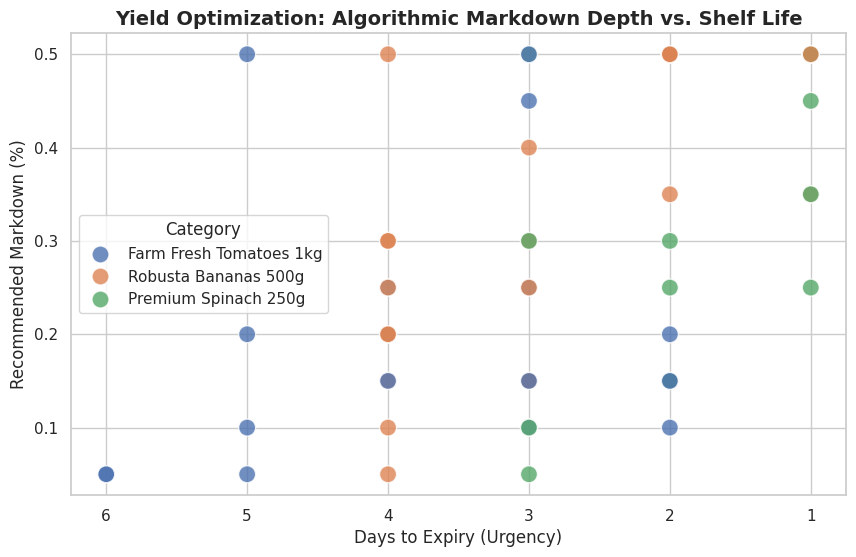

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set up the visualization style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 2. Plot the markdown elasticity curve
sns.scatterplot(
    data=actionable_markdowns,
    x='days_to_expiry',
    y='recommended_markdown',
    hue='sku_name',
    s=150,
    alpha=0.8,
    palette="deep"
)

# 3. Format the chart for presentation
plt.title('Yield Optimization: Algorithmic Markdown Depth vs. Shelf Life', fontsize=14, fontweight='bold')
plt.xlabel('Days to Expiry (Urgency)', fontsize=12)
plt.ylabel('Recommended Markdown (%)', fontsize=12)
plt.gca().invert_xaxis()  # Urgency increases as days approach zero
plt.legend(title='Category')

# 4. Display the chart
plt.show()